#### Import packeges


In [1]:
import numpy as np
from matplotlib import pyplot as plt
import math
from scipy import optimize

import pandas as pd
import seaborn as sns
import os
%matplotlib inline

#### Parametrs


In [2]:

SENSOR_DATA_TOTAL = 'humi'  # 'humi' or 'temp'
SIMILARITY_METHOD = 'MAAPE'  # 'correlation', 'MSE'  .. ........  To test both and find references
INTERPOLATION_METHOD = 'quadratic'  # 'linear', 'quadratic'   ........... is it better to be linear or qudaratic?
SIMILARITY_THRESHOLD = 2            #...............######################## I have to motivate this value or find it in statistic "significant"

file_list = [f for f in os.listdir('../data') if f.endswith(('.txt', '.csv'))]

#### Import dataset


In [3]:
SENSOR_DATA_PD = pd.read_csv(f"../data/HumiAndTemp12mins.txt", sep='\s+', engine='python')
print(len(SENSOR_DATA_PD))
SENSOR_DATA_PD.head()


371


,Humi,Temp
0,41.7,24.4
1,41.7,24.4
2,41.7,24.4
3,41.7,24.4
4,41.8,24.4


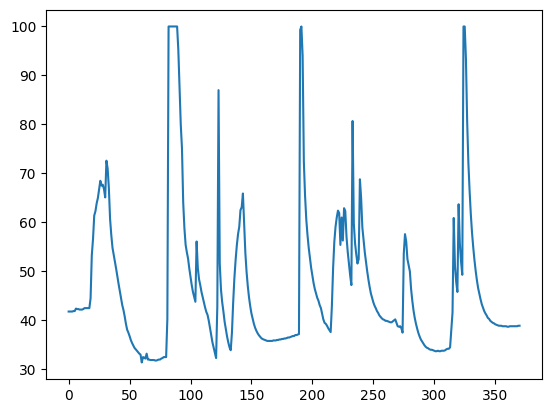

length of data total (training + testing) =  371


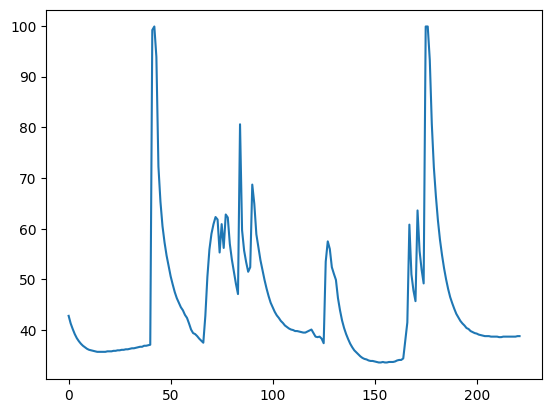

length of data for training =  222


In [4]:


if SENSOR_DATA_TOTAL == 'temp':
    SENSOR_DATA_TOTAL = np.array(SENSOR_DATA_PD.Temp) 

if SENSOR_DATA_TOTAL == 'humi':
    SENSOR_DATA_TOTAL =np.array(SENSOR_DATA_PD.Humi)
    
plt.plot(SENSOR_DATA_TOTAL)
plt.show()
print('length of data total (training + testing) = ',len(SENSOR_DATA_TOTAL))


SENSOR_DATA= SENSOR_DATA_TOTAL[149:]
#SENSOR_DATA = SENSOR_DATA_TOTAL[:round(len(SENSOR_DATA_TOTAL)*0.4)]

plt.plot(SENSOR_DATA)
plt.show()

print('length of data for training = ',len(SENSOR_DATA))




#### Interpolation functions


In [5]:
def interp_linear(x, y):
    '''Linear interpolation'''
    res = []
    for i in range(1, len(x)):
        slope = (y[i] - y[i - 1]) / (x[i] - x[i - 1])
        l = y[i] - slope * x[i]
        res.extend([slope * x_betw + l for x_betw in range(x[i - 1], x[i])])
    res.append(y[-1])
    return np.array(res)

In [6]:
def interp_quadratic(x, y):
    '''Quadratic interpolation'''
    if len(x) == 2:
        print('Use linear interpolation instead of polinomial when number of samples equals 2')
        return interp_line(x, y)
    a = ((y[2] - y[0]) / ((x[2] - x[0]) * (x[2] - x[1])) - 
             (y[1] - y[0]) / ((x[1] - x[0]) * (x[2] - x[1])))
    b = (a * (x[0] ** 2 - x[1] ** 2) + y[1] - y[0]) / (x[1] - x[0])
    c = y[0] - a * x[0] ** 2 - b * x[0]
    res = [a * x_betw ** 2 + b * x_betw + c for x_betw in range(x[0], x[2])]
    for i in range(1, len(x) - 2):
        a = ((y[i + 2] - y[i]) / ((x[i + 2] - x[i]) * (x[i + 2] - x[i + 1])) - 
             (y[i + 1] - y[i]) / ((x[i + 1] - x[i]) * (x[i + 2] - x[i + 1])))
        b = (a * (x[i] ** 2 - x[i + 1] ** 2) + y[i + 1] - y[i]) / (x[i + 1] - x[i])
        c = y[i] - a * x[i] ** 2 - b * x[i]
        res.extend([a * x_betw ** 2 + b * x_betw + c for x_betw in range(x[i + 1], x[i + 2])])  
    res.append(y[-1])
    return np.array(res)

Similarity functions


In [7]:
def cor(f, g):
    '''Correlation function that you provide'''
    return 100 * np.dot(f, g) / (math.sqrt(np.dot(f, f)) * math.sqrt(np.dot(g, g)))

In [8]:
#chekc this article for MAAPE "A new metric of absolute percentage error for intermittent demand forecasts"
def MAAPE(f,g):
    EPSILON = 1e-10
    return np.mean(np.arctan(np.abs((f - g) / (f + EPSILON)))) * 100
     

In [9]:
other = (SENSOR_DATA, INTERPOLATION_METHOD, SIMILARITY_METHOD, SIMILARITY_THRESHOLD)

In [10]:
def measure(params, *other):                                                        
    '''Returns the number of measurements for certain K and C'''         #.........  params means k and c same number?
    data, interpolation, error, min_sim = other         #...........#############......what is this? how to use it?
    K, C = params                                      #...........#############
    prev_meas = 0
    new_meas = max(1, int(round(K)))
    measurements = []
    days = []
    while new_meas < len(data):
        slope = abs((data[new_meas] - data[prev_meas])) / (new_meas - prev_meas) #prev_meas and new_meas are used as an index (days)
        measurements.append(data[prev_meas])                                   
        days.append(prev_meas)                                             
        prev_meas, new_meas = new_meas, new_meas + max(1, int(round(K - C * slope)))
    measurements.append(data[prev_meas])
    days.append(prev_meas)
    num_of_meas = len(days)
    if prev_meas != len(data) - 1:                        # to include the last measurement, in case the last point from DSRA is not the last point of the oriognal data (to include the last measurements  even it is no considered)
        measurements.append(data[-1])
        days.append(len(data) - 1)
        
    if interpolation == 'linear':
        interp_sampl = interp_linear(days, measurements)
    else:
        interp_sampl = interp_quadratic(days, measurements)
    
    if error == 'correlation':
        similarity = cor(data, interp_sampl)
    else:
        similarity = MAAPE(data, interp_sampl)
        
        # IF WE USE ERROR = correlation THEN "similarity <= min_sim" this has to be adjusted to the opposite IN ALL OF THE CODES
        

    return num_of_meas if similarity <= min_sim else len(SENSOR_DATA)  #.... to return len of data (i.e. 780) incase less than 99.97, is that correct?

In [11]:
def plot2d(data, range_k, range_c, min_sim=SIMILARITY_THRESHOLD, interpolation=INTERPOLATION_METHOD, error=SIMILARITY_METHOD):
    '''Plots the graph of the dependence the number of measurements on K and C'''  
    z = []                                                                         #elaborate on the figure
    x = []
    y = []
    for k in range_k:
        for c in range_c:
            prev_meas = 0
            new_meas = max(1, int(round(k)))
            measurements = []
            days = []
            while new_meas < len(data):
                slope = abs((data[new_meas] - data[prev_meas])) / (new_meas - prev_meas)
                measurements.append(data[prev_meas])
                days.append(prev_meas)
                prev_meas, new_meas = new_meas, new_meas + max(1, int(round(k - c * slope))) # to use it in precise applications, e.g.ADC, maybe change the 1 to clock speed, so the decision of the next measurements isnot a time value that the microcontroller can not perform . also the roun, maybe you can put the number of digit that the microcontroller can catch  
            measurements.append(data[prev_meas])
            days.append(prev_meas)
            num_of_meas = len(days)
            if prev_meas != len(data) - 1:                     # to onclude the last measurement, even it is no considered
                measurements.append(data[-1])
                days.append(len(data) - 1)

            if interpolation == 'linear':
                interp_sampl = interp_linear(days, measurements)
            else:
                interp_sampl = interp_quadratic(days, measurements)
            
            similarity = MAAPE(data, interp_sampl)
            
            if similarity <= min_sim:
                z.append(len(days))
                x.append(k)
                y.append(c)
    mx = max(z)
    colors = [i / mx for i in z]                       
    plt.scatter(x, y, c=colors, alpha=1) 
    plt.xlabel('E')
    plt.ylabel('S')
    cbar = plt.colorbar()
    cbar.set_label('no. of measurements')   

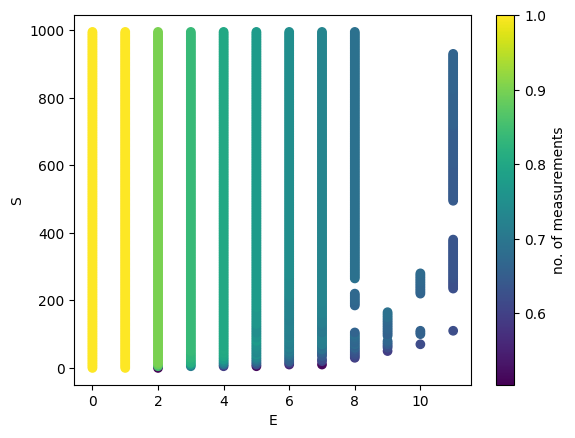

In [12]:

#please find your bounds

plot2d(SENSOR_DATA, range(0, 100, 1), range(-500, 1000, 5))  

plt.show()

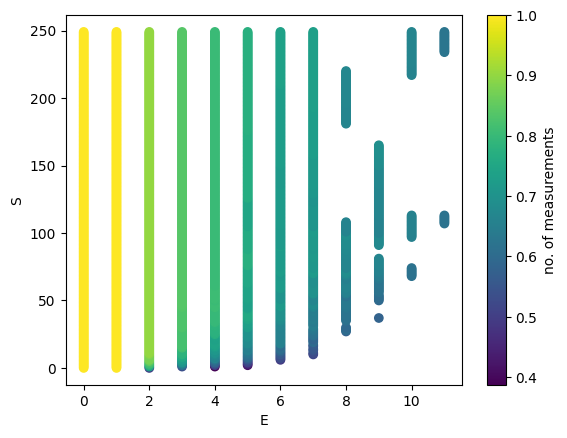

In [13]:
plot2d(SENSOR_DATA, range(0, 40, 1), range(-20, 250, 1)) #E S
plt.show()                                                   #..... the values of k is 120, c is 12.2K. When you check this
                                                                #in the figure you find it in the white area. what does that mean? 

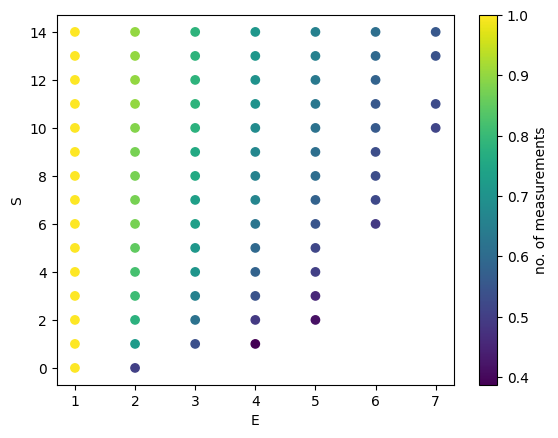

In [14]:
plot2d(SENSOR_DATA, range(1, 9, 1), range(-3, 15, 1)) #E S
plt.show()  

In [15]:
def PLOT(data, K, C, original_signal=True, interpolation=INTERPOLATION_METHOD, error=SIMILARITY_METHOD):
    '''Plots groundtruth and measured with optimized sampling sensor signal'''
    prev_meas = 0
    new_meas = max(1, int(round(K))) # why to code as int()
    measurements = []
    days = []
    while new_meas < len(data):
        slope = abs((data[new_meas] - data[prev_meas])) / (new_meas - prev_meas)
        measurements.append(data[prev_meas])
        days.append(prev_meas)
        prev_meas, new_meas = new_meas, new_meas + max(1, int(round(K - C * slope)))  # to use it in precise applications, e.g.ADC, maybe change the 1 to clock speed, so the decision of the next measurements isnot a time value that the microcontroller can not perform . also the roun, maybe you can put the number of digit that the microcontroller can catch  
    measurements.append(data[prev_meas])
    days.append(prev_meas)
    num_of_meas = len(days)
    if prev_meas != len(data) - 1:
        measurements.append(data[-1])
        days.append(len(data) - 1)
    
    if interpolation == 'linear':
        plotList = interp_linear(days, measurements)
    else:
        plotList = interp_quadratic(days, measurements)
    
    similarity = MAAPE(data, plotList)   #cor(data, plotList)
    plt.plot(plotList,'--' ,label = f'{K} - {C} * slope')
    
    if original_signal:
        plt.plot(SENSOR_DATA, label = 'Original signal')
    plt.scatter(days, np.zeros(len(days)),  edgecolors='black' ,label = 'sampling interval')
    plt.legend(loc = 'best')    
    plt.grid(ls = '--')
    plt.title(f'Number of samples = {len(days)}, error = {similarity} %, sampling reduced by = {abs((round(len(days)/len(SENSOR_DATA),2 )*100)-100) }% ')

#### Optimization

##### The documentation about used algorithm of optimization - https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.dual_annealing.html


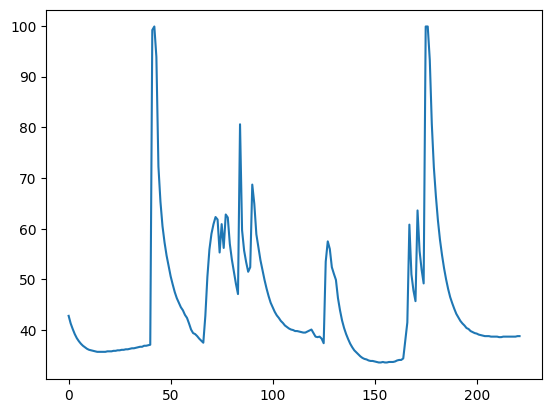

In [16]:
SENSOR_DATA= SENSOR_DATA_TOTAL[149:]
plt.plot(SENSOR_DATA)

In [17]:
from scipy.optimize import dual_annealing
bounds = [(1, 8), (-1, 15)]  # bounds for K and C
resdual = dual_annealing(measure, bounds, args=other, maxiter=10000)  # optimization argument of maxiter was 50000 origionally
K, C = resdual.x

K= 3.691430121487917 and C=0.2605000861257665


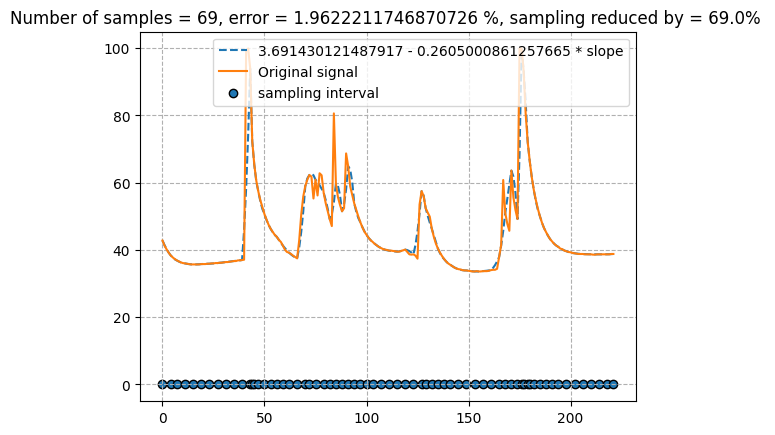

In [18]:
PLOT(SENSOR_DATA, K, C)
print(f'K= {K} and C={C}')

## Testing


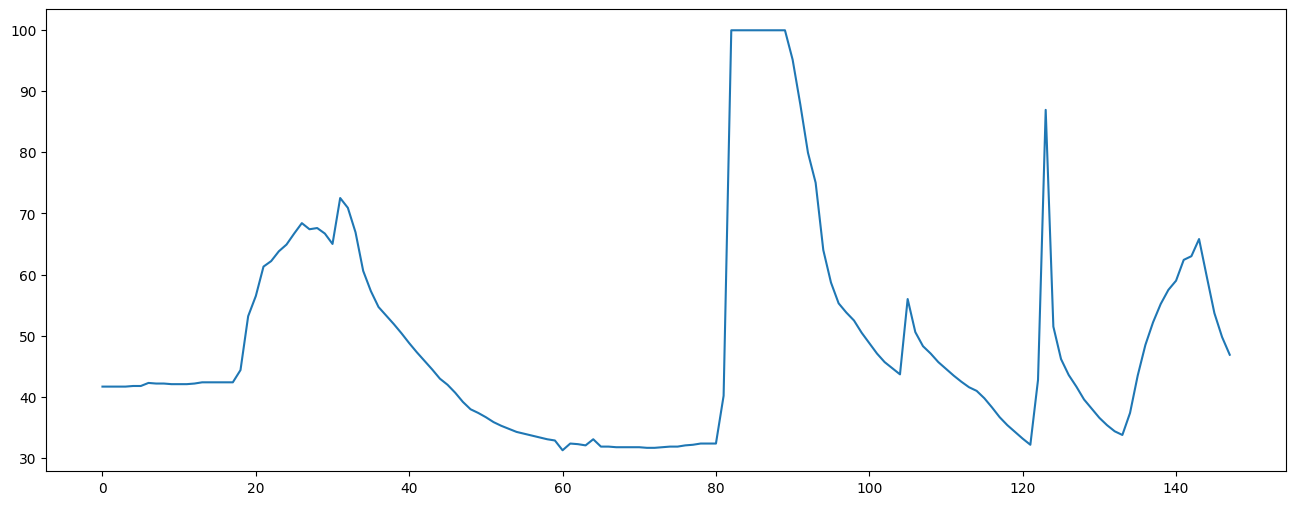

148

In [19]:
SENSOR_DATA = SENSOR_DATA_TOTAL[:round(len(SENSOR_DATA_TOTAL)*0.4)]
plt.figure(figsize = (16, 6))
#PLOT(SENSOR_DATA, K, C)
plt.plot(SENSOR_DATA)
plt.show()
len(SENSOR_DATA)

Text(0, 0.5, 'Humidity (RH%)')

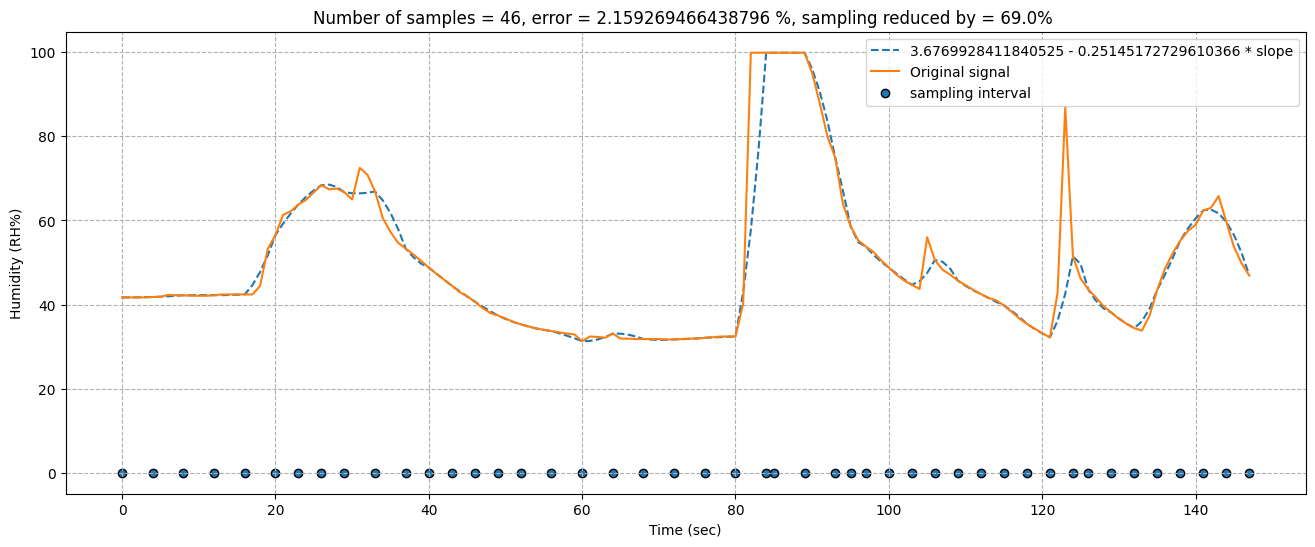

In [20]:
#the sameas the above plot but with x and y axis naming (time and humidity)

K= 3.6769928411840525
C=0.25145172729610366


SENSOR_DATA = SENSOR_DATA_TOTAL[:round(len(SENSOR_DATA_TOTAL)*0.4)]
plt.figure(figsize = (16, 6))
PLOT(SENSOR_DATA, K, C)

plt.xlabel('Time (sec)')
plt.ylabel('Humidity (RH%)')